# COGS 108 Final Project
# **Clustering and Statistical Analysis of San Diego Parking Citations**

---
## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [ `X` ] YES - make available
* [  ] NO - keep private

---
## Abstract

Urban parking enforcement patterns reveal critical insights into municipal resource allocation, spatial equity, and behavioral dynamics. This study analyzes 475,638 parking citations issued across San Diego in 2024 to identify and characterize distinct street-level enforcement typologies. Through rigorous standardization and cleaning, we constructed a unified event-level dataset with standardized location identifiers, violation categories, and temporal features including day-of-week patterns, seasonal distributions, and violation-type proportions.

We employed K-means clustering with engineered spatial-temporal features to uncover natural groupings in citation behavior. Model selection via silhouette analysis identified a two-cluster solution that distinguished typical low-activity streets from high-intensity enforcement hotspots concentrated in commercial corridors. These clusters exhibited statistically significant differences in violation-type distributions (chi-square test, p < 0.001), fine amount structures (ANOVA test, p < 0.001), and temporal patterns. High-volume clusters were dominated by meter-related and loading zone violations, while typical streets showed greater proportions of street sweeping and signage violations.

Our findings demonstrate that San Diego's parking enforcement is highly concentrated rather than uniformly distributed, with a small subset of streets accounting for disproportionate citation volumes and revenue. These differences have implications for enforcement equity, resource allocation, and policy design.

---
## Authors

- Toby Zhang: Data curation, Software, Inference
- Rohan Marda: Data curation, Software , Modeling 
- Luke Huang: Writing, Analysis, Visualization
- Tyler Wong: Writing, Analysis, Visualization

---
## Research Question

**Can San Diego streets be grouped into distinct meaningful clusters based on their weekly citation volume and violation-type proportions in 2024, and do these clusters show significant differences in violation-type distributions and average fine amounts?**

---
## Background and Prior Work

Parking citations are a valuable lens through which to study urban enforcement dynamics, revenue generation, and spatial behavioral patterns. In cities, it has observed that citation volumes are unevenly distributed across streets and neighborhoods, and that both the types of violations and fine amounts can vary substantially. For example, in a study of parking tickets across 16 U.S. cities, Noli Brazil (2024) found that citation burdens are higher in neighborhoods with higher percentages of renters, younger adults, and Black residents <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). Such findings suggest that the data have structure beyond simple counts—there are meaningful differences by location, violation-type, and potentially enforcement practices. <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

More specifically, research that uses clustering or unsupervised methods on parking or violation data points toward the possibility of grouping spatial units by their violation-profiles. For instance, SS Channamallu et al. (2025) applied a cluster-based analysis of parking satisfaction and strategies, identifying distinct user or location clusters based on violation type and parking conditions <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3). Additionally, a study titled “Understanding Urban On-Street Parking Violations” analysed 10,396 violation records and examined temporal, spatial and violation-type determinants of those events (2019)<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4). These studies provide methodological precedent for your proposed approach—grouping streets by characteristics of citation volume and violation-type proportions—and indicate that such clustering can reveal meaningful typologies of urban enforcement.

In light of this prior work, our research question—whether streets in San Diego can be grouped into meaningful clusters based on their weekly citation volume and violation-type proportions, and whether those clusters differ significantly in violation-type distributions and average fine amounts—is well grounded. The existence of spatial and typological variation in citation data is documented; clustering methods have been used successfully in related parking-violation contexts; and the differences in fine amounts and violation types across locations are also well established. What remains novel is applying these methods at the street level in San Diego, using weekly volumes and detailed violation-type proportions, and then testing for differences in average fines across clusters.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Brazil, N., Vang, B., & Abdelnur, H. (2024). **Neighborhood inequality in government fines: The case of parking tickets in 16 U.S. cities**. Cities, 152(103), 105229. https://www.sciencedirect.com/science/article/pii/S0264275124004438. Accessed 12 November 2025.
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Brazil, N. (2018). **The Unequal Spatial Distribution of City Government Fines: The Case of Parking Tickets in Los Angeles**. Urban Affairs Review. https://nbrazil.faculty.ucdavis.edu/wp-content/uploads/sites/481/2018/07/brazil_parking_tickets_uar_2018. Accessed 12 November 2025.
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Channamallu, Sai Sneha, et al. **Cluster-Based Analysis of Parking Satisfaction and Strategies.** Transportation Research Procedia, vol. 90, 27 June 2025, pp. 790–797, www.sciencedirect.com/science/article/pii/S2352146525005885, https://doi.org/10.1016/j.trpro.2025.06.078. Accessed 12 November 2025.
4. <a name="cite_note-4"></a> [^](#cite_ref-4) Li, L., Gao, J., Liang, Y., Marks, D., Kang, J., & Li, Y. (2019). **Understanding Urban On-Street Parking Violations**. Transportation Research Record. https://journals.sagepub.com/doi/10.1177/03611981251378140. Accessed 12 November 2025.

---
## Hypothesis

**We hypothesize that streets will cluster into distinct low-, medium-, and high-volume citation groups, and that high-volume streets will have significantly different citation patterns - specifically, a higher proportion of meter-expiration, tow-away zone, and other high-turnover enforcement violations**

We expect this because high-traffic commercial areas typically experience more short-term parking turnover, stricter enforcement, and greater demand for curb space, which contributes to both higher citation volume and different mixes of violation types. Based on urban land-use and enforcement patterns, we anticipate these clusters will reveal meaningful structural differences between low-activity residential streets and high-pressure commercial corridors.

---
## Data

### Data overview

In [1]:
# Setup code -- Run only once after cloning!!! 
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('./modules')

import get_data
datafiles = [
    {'url': 'https://drive.google.com/uc?export=download&id=1zmubJLzsTN-_L2glokePj9YISZ5Ya94-', 'filename': 'parking_citations_2024_part1_datasd.csv'},
    {'url': 'https://drive.google.com/uc?export=download&id=1XOuzt5l4FegwjjcboIvjuHPwrSdsZ1Xk', 'filename': 'parking_citations_2024_part2_datasd.csv'}
]

get_data.get_raw(datafiles, destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:07<00:07,  7.34s/it]

Successfully downloaded: parking_citations_2024_part1_datasd.csv


Overall Download Progress: 100%|██████████| 2/2 [00:20<00:00, 10.12s/it]

Successfully downloaded: parking_citations_2024_part2_datasd.csv


### Dataset Name: Parking Citations San Diego 2024
  - Link to the dataset: [https://data.sandiego.gov/datasets/parking-citations/](https://data.sandiego.gov/datasets/parking-citations/)

  - Number of observations: 475,638

  - Number of variables: 8
    - ```citation_id```: Unique citation identifier.
    - ```date_issue```: Date citation was issued.
    - ```date_creation```: Date citation was created. This refers to when the citation was entered into the database.
    - ```location```: Street number and name of where the citation was issued. (eg. 1400 Market St)
    - ```sector1```: The sector of Parking Enforcement issuing the citation. (eg. CSD(I) Parking Enf)
    - ```vio_code```: The section of the law violated. (eg. 86.0124 SDMC)
    - ```vio_desc```: A description of the violation. (eg. Expired meter)
    - ```vio_fine```: The fine assessed at the time of citation in USD ($). (eg. 52.5)

  - The dataset is publicly available under California transparency laws and maintained by the City of San Diego's Performance and Analytics Department (PandA), and thus can be generally considered reliable, but it may contain errors or inconsistencies common in administrative data. One noteworthy shortcoming is the lack of a time of cite, which would have allowed finer grained time-series analysis. The data also may have slight inconsistencies and biases as the data is collected from several agencies (Parking Enforcement, Street Sweepers, Police Officers, etc.), each of which may have differing operating procuedures. Furthermore, officers may unconciously target certain areas (eg. Downtown) and cars (eg. classic or luxury vehicles) more often, which could cause an overrepresentation of those groups in our dataset.

###### Note: Although we are using a single dataset, the data provider split it into two separate files. We imported both files, concatenated them, and will treat them as a single dataset for all analyses. 
---

In [2]:
# load data and concatenate
part1 = pd.read_csv('data/00-raw/parking_citations_2024_part1_datasd.csv')
part2 = pd.read_csv('data/00-raw/parking_citations_2024_part2_datasd.csv')
df = pd.concat([part1, part2], axis=0)

df.info()

C:\Users\rohan\AppData\Local\Temp\ipykernel_21668\3055169173.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  part1 = pd.read_csv('data/00-raw/parking_citations_2024_part1_datasd.csv')


<class 'pandas.core.frame.DataFrame'>
Index: 475638 entries, 0 to 248256
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   citation_id    475638 non-null  object 
 1   date_issue     475638 non-null  object 
 2   date_creation  475638 non-null  object 
 3   location       475563 non-null  object 
 4   sector1        475638 non-null  object 
 5   vio_code       475638 non-null  object 
 6   vio_desc       475638 non-null  object 
 7   vio_fine       475638 non-null  float64
dtypes: float64(1), object(7)
memory usage: 32.7+ MB


C:\Users\rohan\AppData\Local\Temp\ipykernel_21668\3055169173.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  part2 = pd.read_csv('data/00-raw/parking_citations_2024_part2_datasd.csv')


In [3]:
df.head()

,citation_id,date_issue,date_creation,location,sector1,vio_code,vio_desc,vio_fine
0,101637347,2024-01-01,2024-02-01,3600 CALIFORNIA STREET,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
1,101660865,2024-01-01,2024-01-21,1500 C ST,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
2,101660866,2024-01-01,2024-01-21,1400 B ST,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
3,101496678,2024-01-01,2024-01-23,300 5TH AVENUE,CSD (S) POLICE,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5
4,59899217,2024-01-01,2024-01-02,MARINERS POINT LOT 3200 MARINERS WAY,CSD (S) POLICE,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5


The most pertinent variables that we will consider are ```location```, ```vio_desc```, and ```vio_fine```.
- ```location```: This is the primary unit for aggregation and clustering in this project. Standardization is necessary because abbreviations and inconsistencies (e.g., “St” vs “St.” or “Ave” vs “Ave.”) exist.
- ```vio_desc```: Each description is accompanied by the respective section of the California Vehicle Code (CVC), San Diego Municipal Code (SDMC), or other relevant law in ```vio_code```. Would be used to further understand how violation types vary by location.
- ```vio_fine```: Fines vary by violation type and location, and we wish to further study how variations in location and violation affect fines.

The data is already tidy. There is a row for each observation (```citation_id```), and each observation has a column for a variable (```date_issue```, ```location```, ```vio_fine```, etc.). The data follows a consistent layout that is suitable for analysis.

In [4]:
# check missingness, if any
df[df.isna().any(axis=1)]

,citation_id,date_issue,date_creation,location,sector1,vio_code,vio_desc,vio_fine
2348,59899306,2024-01-03,2024-01-03,NaN,CSD (S) POLICE,22507.8(a)CVC,DISABLED PARKING,0.0
3465,101709578,2024-01-04,2024-01-21,NaN,CSD (S) POLICE,4000(A)1 CVC,EXPIRED REGISTRATION,52.5
17623,59944425,2024-01-13,2024-01-13,NaN,CSD (I) PARKING ENF,86.0126 SDMC,EXPIRED METER,42.5
17626,59944424,2024-01-13,2024-01-13,NaN,CSD (I) PARKING ENF,86.0126 SDMC,EXPIRED METER,42.5
21386,101709841,2024-01-17,2024-02-01,NaN,CSD (S) POLICE,4000(A)1 CVC,EXPIRED REGISTRATION,52.5
...,...,...,...,...,...,...,...,...
195260,101709147,2024-11-16,2025-04-04,NaN,CSD (S) POLICE,4000(A)1 CVC,EXPIRED REGISTRATION,52.5
211376,61164247,2024-11-30,2024-11-30,NaN,CSD (I) PARKING ENF,22514 CVC,FIRE HYDRANT,77.5
231488,101699632,2024-12-15,2025-01-16,NaN,CSD (S) POLICE,86.0112(F) SDMC,RED ZONE,77.5
239962,101650345,2024-12-22,2025-02-10,NaN,CSD (I) PARKING ENF,22500(C) CVC,"SIGNS, RED ZONES",52.5


75 citations are missing ```location``` data. This could be because the citations were issued on unnamed roads, or the issuing officer did not know the location. Missingness is extremely rare (0.015%), and because these rows represent such a small proportion, dropping them will not affect downstream analysis

In [5]:
df = df.dropna(how='any')
print('Updated shape:', df.shape)

Updated shape: (475563, 8)


The location data available in the dataset is extremely fine grained, providing specific street numbers. We removed street numbers because our clustering is at the street level, not the address level. Keeping numbers would fragment the data and produce thousands of meaningless micro-clusters. Moreover, street names were not consistently stored, evidenced by multiple abbreviations for the same word (eg. 'ave' and 'av' for 'avenue'). We utilized a large dictionary of common street abbreviations to strandardize location names and stripped street numbers to allow for generalization.

Lastly, we dropped ```date_creation``` as it provided redudant and irrelevant information. ```date_issue``` provides the true date of the citation.

In [6]:
# number of unqiue locations before cleaning
print('(Before clean) No. unique locations', df['location'].value_counts().shape[0])

# removing street numbers
cleaned_df = df.copy()
cleaned_df['location'] = cleaned_df['location'].apply(lambda x: ' '.join(x.split(' ')[1:]).strip() if x.split(' ')[0].isnumeric() else x)
cleaned_df['location'].value_counts()

# standardize names
def clean_location(location):
    street_standardization = {
    'street':'st','st.':'st','avenue':'ave','ave.':'ave','av':'ave','av.':'ave',
    'boulevard':'blvd','blvd.':'blvd','road':'rd','rd.':'rd','drive':'dr','dr.':'dr',
    'lane':'ln','ln.':'ln','court':'ct','ct.':'ct','place':'pl','pl.':'pl','circle':'cir',
    'cir.':'cir','terrace':'ter','ter.':'ter','parkway':'pkwy','pkwy.':'pkwy','way':'way',
    'wy.':'way','highway':'hwy','driveway':'drwy','plaza':'plz','plz.':'plz',
    'center':'ctr','centre':'ctr','ctr.':'ctr','heights':'hts','trail':'trl','loop':'loop',
    'vista':'vsta','hill':'hl','hills':'hls','ridge':'rdg','valley':'vly','grove':'grv',
    'mount':'mt','mountain':'mtn','creek':'crk','harbor':'hbr','harbour':'hbr','point':'pt',
    'landing':'lndg','meadow':'mdw','meadows':'mdws','bay':'bay','shore':'shr','shores':'shrs',
    'park':'park','orchard':'orch','northeast':'ne','ne.':'ne','northwest':'nw','southeast':'se',
    'southwest':'sw','sw.':'sw','first':'1st','second':'2nd','third':'3rd','fourth':'4th',
    'fifth':'5th','sixth':'6th','seventh':'7th','eighth':'8th','ninth':'9th','tenth':'10th',
    'eleventh':'11th','twelfth':'12th','thirteenth':'13th','fourteenth':'14th','fifteenth':'15th',
    'sixteenth':'16th','seventeenth':'17th','eighteenth':'18th','nineteenth':'19th','twentieth':'20th',
    'avenue.':'ave','street.':'st'
    }
    
    tokens = location.lower().split()
    cleaned = [street_standardization.get(tok, tok) for tok in tokens]
    
    return ' '.join(cleaned)

cleaned_df['location'] = cleaned_df['location'].apply(clean_location)
print('(After clean) No. unique locations', cleaned_df['location'].value_counts().shape[0])

# Drop redundant 'date_creation' column
cleaned_df = cleaned_df.drop(columns=['date_creation'])

# converting dates to Timestamp objects for analysis
cleaned_df['date_issue'] = pd.to_datetime(cleaned_df['date_issue'])

cleaned_df.sample(5)

(Before clean) No. unique locations 113188
(After clean) No. unique locations 18447


,citation_id,date_issue,location,sector1,vio_code,vio_desc,vio_fine
112043,61162121,2024-09-17,andros pl,CSD (I) PARKING ENF,86.0111 SDMC,WHEEL CRAMPING-HILL,59.5
214897,61266504,2024-12-03,30th st,CSD (I) PARKING ENF,86.0126 SDMC,EXPIRED METER,42.5
4376,59926707,2024-01-04,brighton ave,CSD (G) STREET SWEEPING,86.0112(E)S DMC,VIOLATION OF SIGNS-STREET SWEEPING,52.5
116168,101669139,2024-04-06,dawson ave,CSD (S) POLICE,22500(L) CVC,SIDEWALK ACCESS RAMP,302.5
195214,61215820,2024-11-15,piper ranch rd,CSD (I) PARKING ENF,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5


### Summary statistics of key variables:

- ```date_issue```

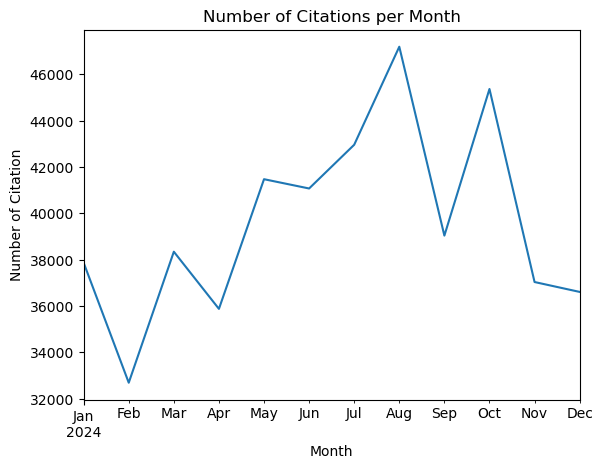

In [7]:
# Line graph of number citations per month
cites_by_month = cleaned_df.groupby(cleaned_df['date_issue'].dt.to_period('M')).count()['citation_id']
cites_by_month.plot(
    kind='line',
    title='Number of Citations per Month',
    xlabel='Month',
    ylabel='Number of Citation')
plt.show()

The line plot of citations does not contain any obvious outliers, and provides some insight into citations numbers over the year.

Citation volume peaks in July-August and again in October. These may correspond to increased street sweeping cycles or tourist traffic. No extreme outliers suggest data collection was stable month-to-month.

- ```vio_desc```

In [8]:
vio_types = cleaned_df['vio_desc'].value_counts()
vio_types

vio_desc
VIOLATION OF SIGNS-STREET SWEEPING           107508
VIOLATION OF SIGNS (SDMC)                     74321
EXPIRED METER                                 69619
RED ZONE                                      39024
PASSENGER ZONE                                21711
                                              ...  
7 1/2 FT OF RAILROAD TRACK                        1
VIOLATION OF SIGNS (CVC)                          1
STANDING CAB WITHIN 100 FT OF ANOTHER CAB         1
EXCEED SIZE (3TONS 6.5FT W 19FT)                  1
VEHICLE NOT MOVED IN 72 HOURS                     1
Name: count, Length: 82, dtype: int64

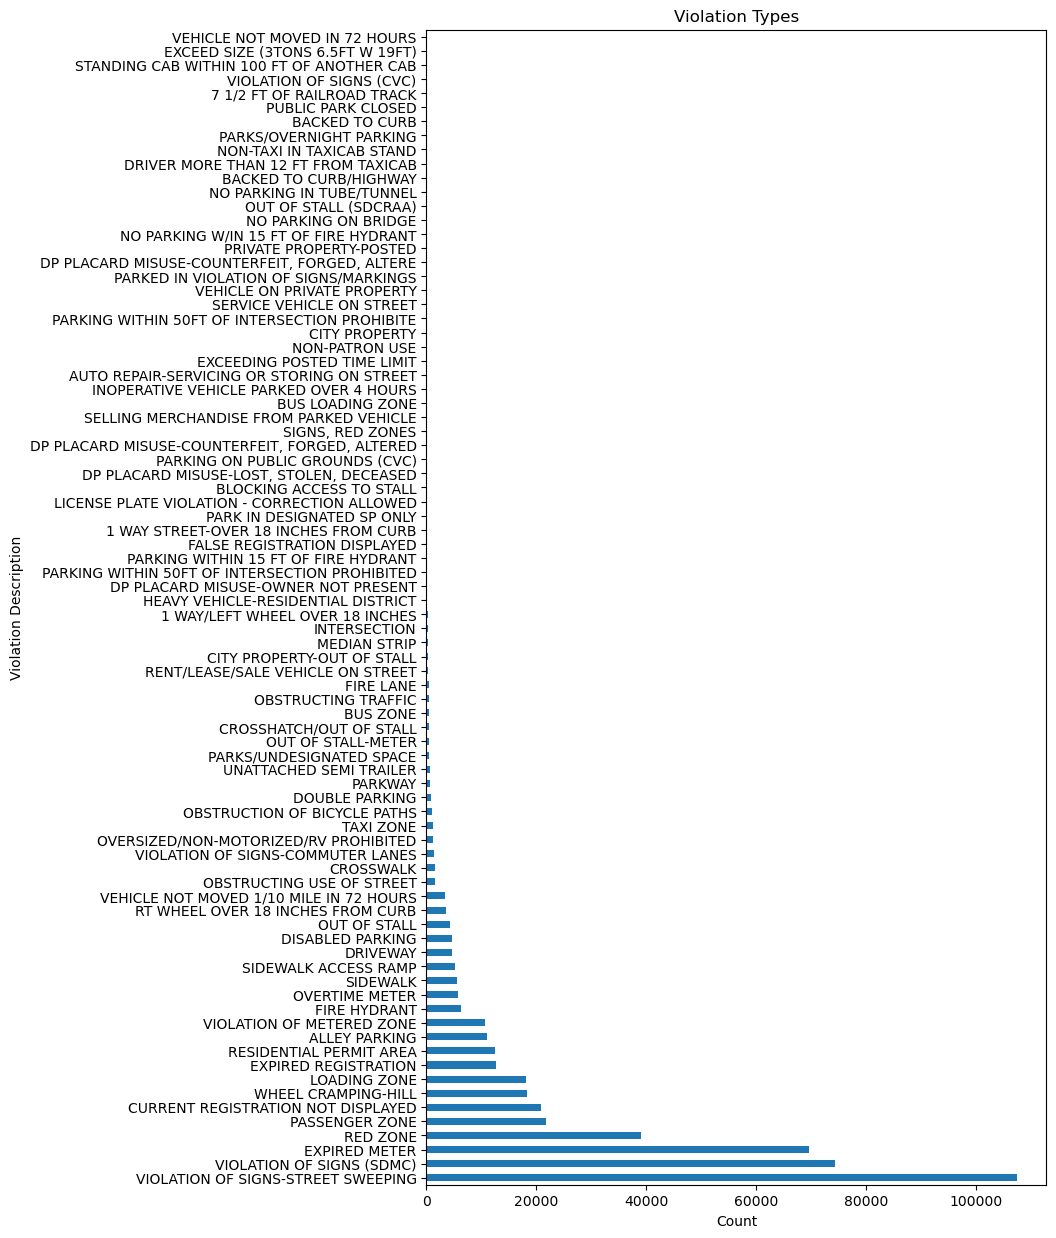

In [9]:
# Bar plot of violation types
plt.figure(figsize=(8, 15))
vio_types.plot(kind='barh', x='count', title='Violation Types', xlabel='Count', ylabel='Violation Description')
plt.show()

We filtered out rare violations (< 4,000 citations) because our analysis compares violation mix proportions across streets. Very rare categories would introduce noise and dominate cluster variance without contributing meaningful street-level patterns.

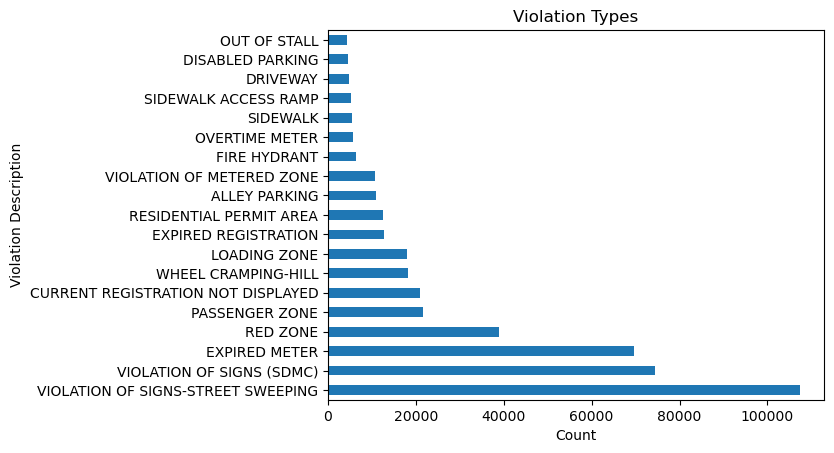

Updated shape: (452702, 7)


In [10]:
# filter out violations with less than 4000 citations
processed_df = cleaned_df.groupby('vio_desc').filter(lambda x: len(x) >= 4000)
vio_types = processed_df['vio_desc'].value_counts()
vio_types.plot(kind='barh', x='count', title='Violation Types', xlabel='Count', ylabel='Violation Description')
plt.show()
print('Updated shape:', processed_df.shape)

- ```vio_fine```

In [11]:
processed_df['vio_fine'].describe()

count    452702.000000
mean         59.150692
std          45.241062
min           0.000000
25%          52.500000
50%          52.500000
75%          52.500000
max         452.500000
Name: vio_fine, dtype: float64

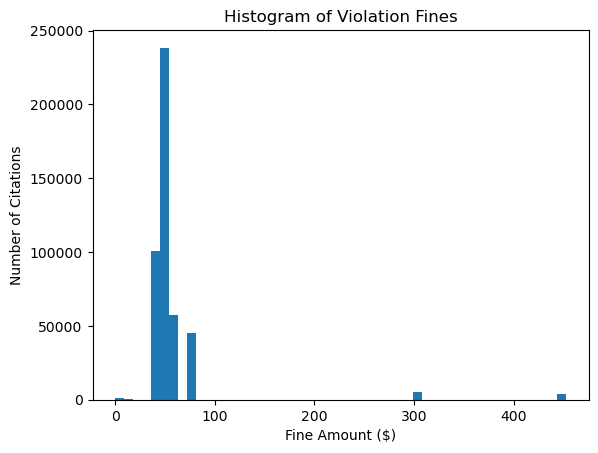

In [12]:
# Histogram of violation fines
fines = processed_df['vio_fine'].plot(kind='hist',
                                      bins=50,
                                      title='Histogram of Violation Fines',
                                      xlabel='Fine Amount ($)',
                                      ylabel='Number of Citations')

Finally, we stored our preprocessed, cleaned, and wrangled data as a ```.csv``` file.

In [13]:
processed_df.to_csv('data/02-processed/citations.csv', index=False)

---
## Exploratory Data Analysis

In [14]:
# load processed data
citations = pd.read_csv('data/02-processed/citations.csv')
citations

,citation_id,date_issue,location,sector1,vio_code,vio_desc,vio_fine
0,101637347,2024-01-01,california st,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
1,101660865,2024-01-01,c st,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
2,101660866,2024-01-01,b st,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
3,101496678,2024-01-01,5th ave,CSD (S) POLICE,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5
4,59899217,2024-01-01,mariners pt lot 3200 mariners way,CSD (S) POLICE,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5
...,...,...,...,...,...,...,...
452697,61309345,2024-12-31,science park,CSD (I) PARKING ENF,86.0112(F) SDMC,RED ZONE,77.5
452698,61287292,2024-12-31,girard ave,CSD (I) PARKING ENF,86.0112(F) SDMC,RED ZONE,77.5
452699,61279704,2024-12-31,mary ln dr,CSD (I) PARKING ENF,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
452700,61279703,2024-12-31,mary ln dr,CSD (I) PARKING ENF,SDMC 86.2014,RESIDENTIAL PERMIT AREA,52.5


##### Street-Level Citation Volume Analysis

This analysis examines how citations are distributted across San Diego streets, which forms the foundation of our clustering approach. We grouped citations by location to gain an understanding of high citation volume streets and their distribution in the city.

In [15]:
# citation volume and fine by location
street_volumes = citations.groupby('location').agg({
    'citation_id': 'count',
    'vio_fine': 'mean'
})

street_volumes.columns = ['total cites', 'avg_fine']
street_volumes = street_volumes.sort_values('total cites', ascending=False)
street_volumes

,total cites,avg_fine
location,,
4th ave,9082,49.259855
6th ave,7870,52.665820
mission blvd,7822,55.925019
island ave,7785,53.296082
5th ave,7506,49.527778
...,...,...
courtney dr,1,37.500000
x 4886 cannington dr,1,52.500000
01-99 31st st,1,77.500000


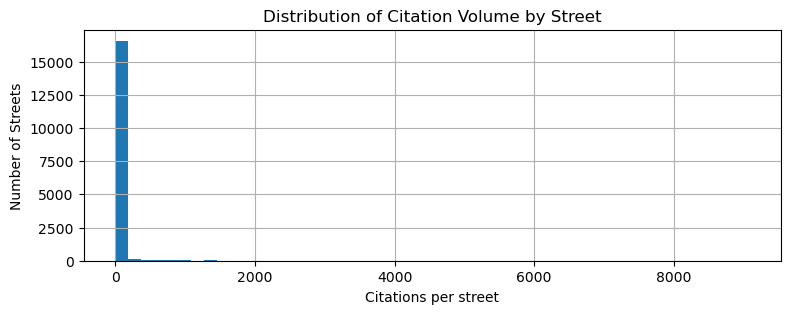

In [16]:
# distribution of citation volume by street
fig, ax1 = plt.subplots(figsize=(9, 3))

street_volumes['total cites'].hist(bins=50, ax=ax1)

ax1.set_xlabel('Citations per street')
ax1.set_ylabel('Number of Streets')
ax1.set_title('Distribution of Citation Volume by Street')

plt.show()

The citation volume distribution shows extreme right skew, with most streets having very few citations while a small number of streets have hundreds of citations. This highly skewed distribution is ideal for clustering because it suggests the presence of distinct street types rather than a continuous spectrum. A log transformation of the y-axis helps reveal the underlying distribution structure, allowing us to identify natural breakpoints that clustering algorithms can exploit to separate streets into meaningful groups.

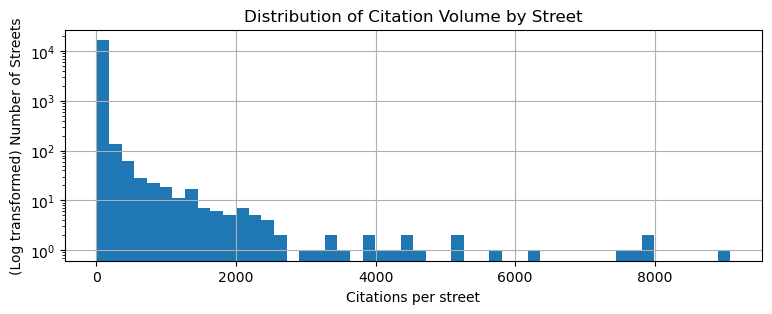

In [17]:
# distribution of log-transformed citation volume by street
fig, ax2 = plt.subplots(figsize=(9, 3))

street_volumes['total cites'].hist(bins=50, ax=ax2)

ax2.set_xlabel('Citations per street')
ax2.set_ylabel('(Log transformed) Number of Streets')
ax2.set_yscale('log')
ax2.set_title('Distribution of Citation Volume by Street')

plt.show()

This log-scale visualization confirms the heavily right-skewed nature of citation volumes across San Diego streets and reveals why clustering is the appropriate analytical approach. The distribution shows three distinct regions that appear naturally separated:

1. **Low-volume streets** (1-10 citations per street): The majority of streets, likely residential areas with minimal enforcement activity
2. **High-volume streets** (10+ citations per street): A small number of high-activity streets, likely 4th Avenue, F street, and other areas in downtown/business districts

These natural breakpoints in the distribution strongly justify using clustering algorithms, as they suggest the existence of distinct street typologies rather than a continuous spectrum. Clustering will allow us to formally identify these groups and test whether they correspond to meaningful differences in violation patterns and urban characteristics.

##### Violation Type and Proportion Analysis

To validate that clustering is appropriate for our research question, we must demonstrate that streets with different citation volumes also exhibit systematically different violation profiles. If high-volume and low-volume streets showed identical violation patterns, clustering would not be meaningful. We classify streets using quartile thresholds to test whether volume differences correspond to distinct violation type patterns - a crucial prerequisite for effective clustering.

In [18]:
# seggregate groups into high and low volume locations
street_citation_counts = citations['location'].value_counts()
volume_quartiles = street_citation_counts.quantile([0.25,0.75])

high_vol = street_citation_counts[street_citation_counts >= volume_quartiles.iloc[1]].index
low_vol = street_citation_counts[street_citation_counts <= volume_quartiles.iloc[0]].index

# compute violation type proportions
high_vol_props = citations[citations['location'].isin(high_vol)]['vio_desc'].value_counts(normalize=True)
low_vol_props = citations[citations['location'].isin(low_vol)]['vio_desc'].value_counts(normalize=True)

Before comparing high vs. low volume streets, let's examine the overall distribution of violation types across all streets to understand the baseline patterns in San Diego's citation data. This will provide context for interpreting the differences we observe between volume groups.

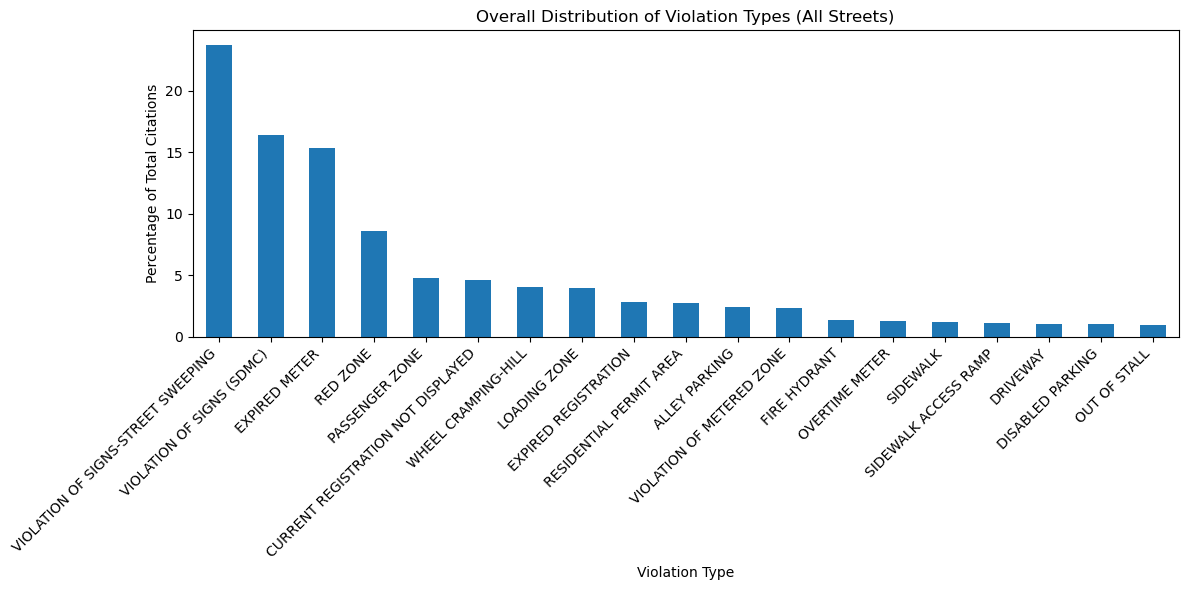

Top 5 violation types overall:
vio_desc
VIOLATION OF SIGNS-STREET SWEEPING    23.748073
VIOLATION OF SIGNS (SDMC)             16.417202
EXPIRED METER                         15.378549
RED ZONE                               8.620240
PASSENGER ZONE                         4.795870
Name: proportion, dtype: float64


In [19]:
# Overall violation type distribution
overall_vio_props = citations['vio_desc'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 6))
overall_vio_props.plot(kind='bar')
plt.title('Overall Distribution of Violation Types (All Streets)')
plt.xlabel('Violation Type')
plt.ylabel('Percentage of Total Citations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 violation types overall:")
print(overall_vio_props.head())

The overall violation type distribution reveals the baseline enforcement patterns across all San Diego streets:

- **Street Sweeping dominates** (~23.75% of all citations), indicating this is the primary enforcement activity citywide. This reflects San Diego's systematic street cleaning schedule that affects all neighborhoods.
- **Violation of Signs** (~16.42% of all citations) is a close secondary. This likely reflects regular parking enforcement activity at public parking lots and city streets.
- **Expired Meter violations** comprise a significant portion (~15.37%), showing the importance of paid parking zones throughout the city, particularly in commercial and downtown areas.

**Long tail distribution**: Many violation types occur less frequently, suggesting specialized enforcement for specific contexts (handicap violations, fire lanes, etc.).

This baseline distribution provides context for understanding how high-volume and low-volume streets might differ from the citywide average. Streets that deviate significantly from these proportions likely represent specific urban contexts (pure residential vs. heavy commercial) that our clustering analysis should be able to identify.

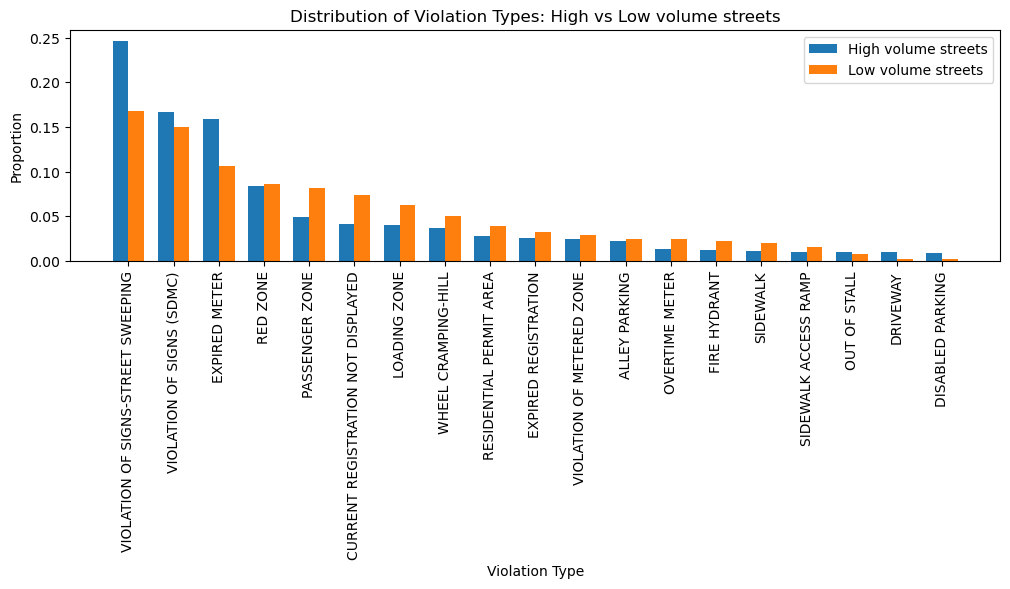

In [20]:
# plot barchart
fig, ax4 = plt.subplots(figsize=(12,3))

x_pos = np.arange(len(high_vol_props))
width = 0.35

b1 = ax4.bar(x_pos - width/2, high_vol_props, width, label='High volume streets')
b2 = ax4.bar(x_pos + width/2, low_vol_props, width, label='Low volume streets')

ax4.set_xlabel('Violation Type')
ax4.set_ylabel('Proportion')
ax4.set_title('Distribution of Violation Types: High vs Low volume streets')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(high_vol_props.index, rotation=90)
ax4.legend()

plt.show()

This comparison shows that although high-volume and low-volume streets share broadly similar violation distributions, there are still notable and meaningful differences that justify further statistical inference.

**Overall shapes are similar**, suggesting both groups follow comparable enforcement patterns. This supports the idea that the two groups are related populations rather than fundamentally different categories.

However, certain violation types diverge enough to matter statistically:
  - **Street Sweeping** violations remain the largest category across both groups, but the magnitude differs substantially, indicating different frequencies or enforcement pressures.
  - **Expired Meter** and **Violation of Signs** show clear differences in proportion, suggesting different usage or compliance behaviors across street groups.
  - Less common categories—such as **No Stopping/Standing**, **Loading Zone**, and **Fire Hydrant** violations—also exhibit small but non-trivial differences that could be statistically significant.

The distributions are close enough to compare directly, yet different enough that formal inference can reveal where those differences matter.


##### Fine Amount Analysis

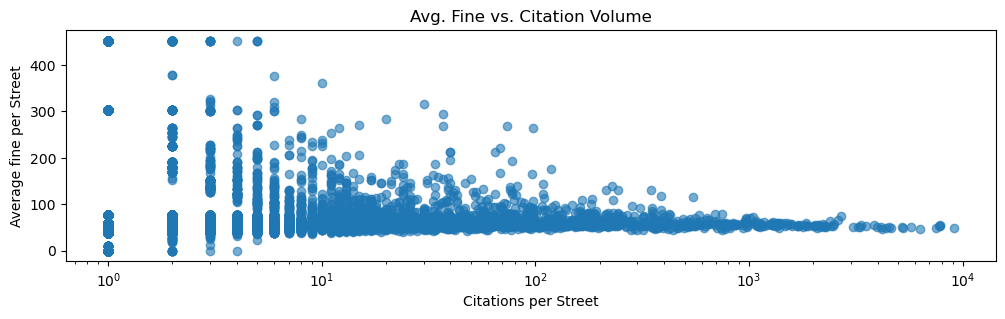

In [21]:
# plot scatterplot of avg fines vs citation volume per street
fig, ax5 = plt.subplots(figsize=(12, 3))

street_fine_stats = citations.groupby('location')['vio_fine'].mean()

some_df = pd.merge(street_citation_counts.rename('total cites'), street_fine_stats.rename('avg_fine'), left_index=True, right_index=True)

ax5.scatter(some_df['total cites'], some_df['avg_fine'], alpha=0.6)
ax5.set_xlabel('Citations per Street')
ax5.set_xscale('log')
ax5.set_ylabel('Average fine per Street')
ax5.set_title('Avg. Fine vs. Citation Volume')

plt.show()

The scatterplot of average fine amount versus citation volume reveal no significant patterns in San Diego's parking enforcement but support our clustering methodology.

1. **No Strong Correlation**: There is no clear linear relationship between citation volume and average fine amount. This indicates that high-volume streets do not necessarily have higher or lower average fines, suggesting that citation volume and fine amounts represent independent dimensions of street characteristics.

2. **Distinct Clusters Emerge**:
   - **Low-volume, varied fines** (1-10 citations): Streets with few citations but wide variation in average fines ($50-$450)
   - **High-volume, converging fines** (10+ citations): Streets with many citations tend toward more uniform fine amounts ($50-$150)

3. **Convergence Pattern**: As citation volume increases, average fine amounts appear to converge toward a narrower range, likely reflecting the dominance of common violation types (like street sweeping or meter violations) on high-traffic streets.

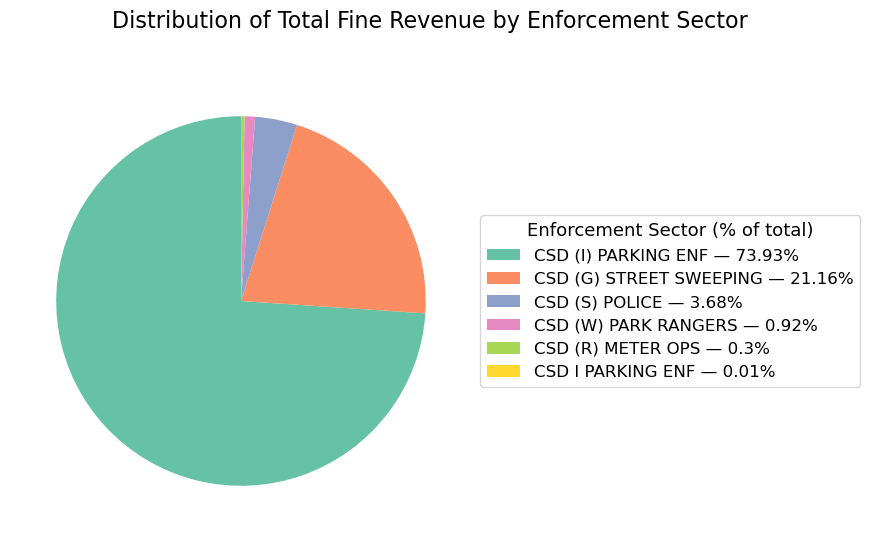

In [22]:
# plot pie chart of fine revenue generated by sector
sector_totals = citations.groupby('sector1')['vio_fine'].sum()

sector_totals = sector_totals.sort_values(ascending=False)
percentages = (sector_totals / sector_totals.sum() * 100).round(2)

colors = plt.cm.Set2(range(len(sector_totals)))    

fig, ax6 = plt.subplots(figsize=(12, 6))

wedges, texts = ax6.pie(
    sector_totals.values,
    startangle=90,
    labels=None,
    colors=colors
)

legend_labels = [
    f"{label} — {pct}%" 
    for label, pct in zip(sector_totals.index, percentages)
]

ax6.legend(
    wedges,
    legend_labels,
    title="Enforcement Sector (% of total)",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title_fontsize=13
)

fig.suptitle(
    'Distribution of Total Fine Revenue by Enforcement Sector',
    fontsize=16,
    x=0.67
)

plt.show()

The pie chart reveals significant concentration in San Diego's parking enforcement revenue streams.

**Revenue Concentration Patterns:**
- **CSD (I) PARKING ENF dominates revenue generation** at 73.93% of total fine collections, indicating this sector handles the majority of high-value or high-volume citation areas. This can likely be explained by the fact that parking enforcement issues parking citations regularly whereas other departments typically issue citations on an as-needed basis. 
- **CSD (G) STREET SWEEPING** contributes 21.16%, representing systematic citywide cleaning that affects all neighborhoods uniformly
- **All other sectors combined** account for less than 5% of total revenue, suggesting specialized or limited enforcement roles

Total Fine Revenue in 2024: $26,777,636.50


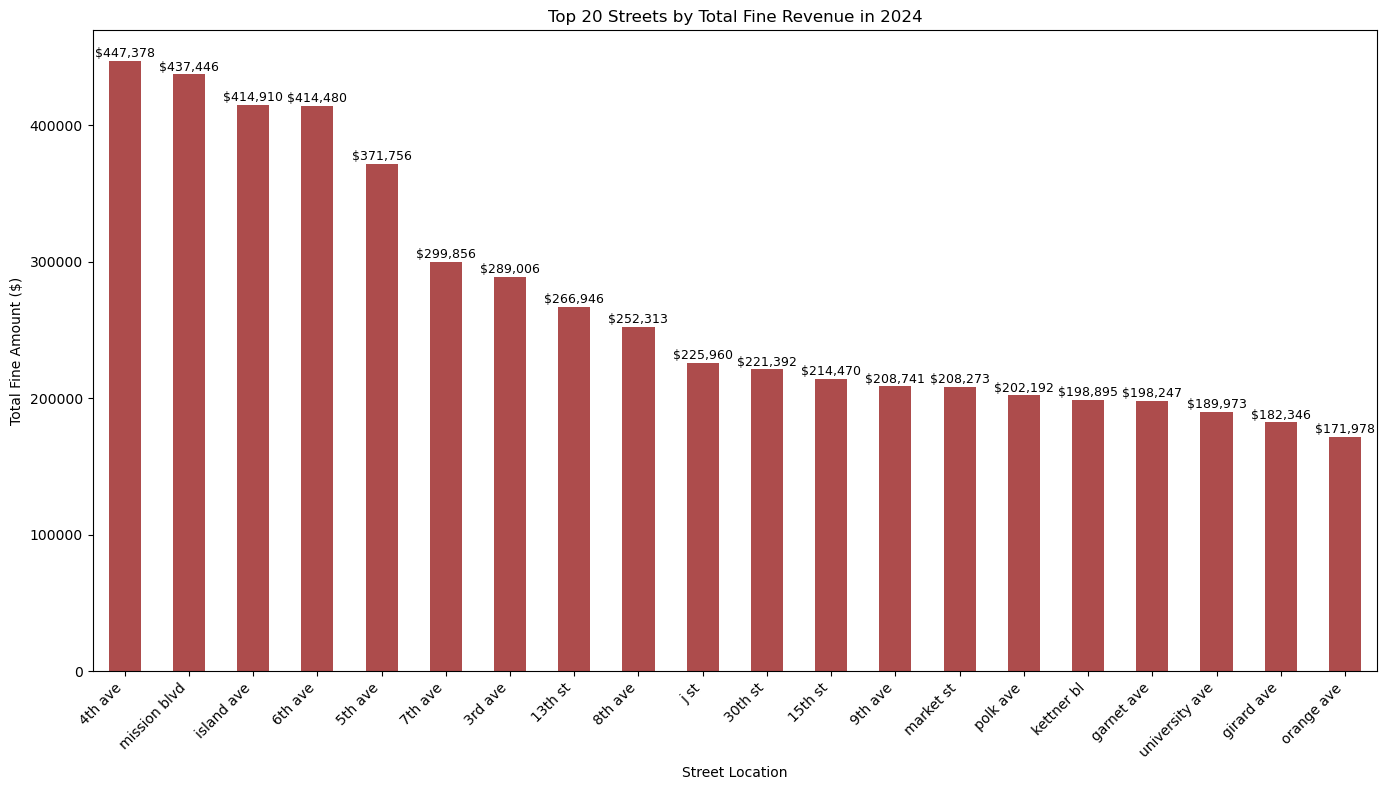

In [23]:
# total revenue in 2024
print(f"Total Fine Revenue in 2024: ${citations['vio_fine'].sum():,.2f}")

# Calculate total fine amounts per street
street_total_fines = citations.groupby('location')['vio_fine'].sum().sort_values(ascending=False)
top_20_streets = street_total_fines.head(20)

# Bar chart of top 20 streets by total fine amount
plt.figure(figsize=(14, 8))
top_20_streets.plot(kind='bar', color='darkred', alpha=0.7)
plt.title('Top 20 Streets by Total Fine Revenue in 2024')
plt.xlabel('Street Location')
plt.ylabel('Total Fine Amount ($)')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for i, v in enumerate(top_20_streets.values):
    plt.text(i, v + 500, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

The bar chart of top 20 streets by total fine revenue reveals the extreme concentration of parking citation revenue in San Diego, providing crucial evidence for our clustering approach.

**Revenue Distribution Insights:**
- **Massive revenue inequality**: The top street generates over $447,000 in fines, while the 20th-ranked street generates approximately $172,000, with the top 120 streets accounting for over 15% of the total revenue.
- **Clear tiering structure**: The revenue drops steadily from rank 1 to 20, with notable breakpoints around positions 5, 10, and 15, suggesting natural groupings that clustering algorithms can exploit.
- **Geographic concentration**: The top revenue streets include major thoroughfares like "4th ave", "mission blvd", "island ave", and numbered streets, indicating these are likely commercial corridors, downtown areas, or major intersections.

The clear revenue hierarchy suggests using clustering to identify these street typologies and test for systematic differences in violation patterns and fine structures would be meaningful

---

## Analysis 1 - K-means Clustering

To examine whether street locations in San Diego show different patterns of parking enforcement, we use K-means clustering, an unsupervised learning method that groups locations based on similarity in their data. In this baseline analysis, each street is described by its total number of citations and its average citation fine, allowing us to see if streets naturally separate into different enforcement groups. K-means works by assigning each location to the nearest cluster center and updating those centers to reduce variation within clusters. To choose the best number of clusters, we use the silhouette score, which measures how well each location fits within its assigned cluster compared to others, with higher values indicating clearer separation. Testing several values of k allows us to evaluate both simple and more complex clustering solutions. This process helps ensure that the final clustering captures real structure in the data rather than noise.

   silhouette_score
k                  
2          0.827363
3          0.855300
4          0.805325
5          0.833696
6          0.837416
7          0.853102
8          0.764893
9          0.774021

Best k based on silhouette: 3


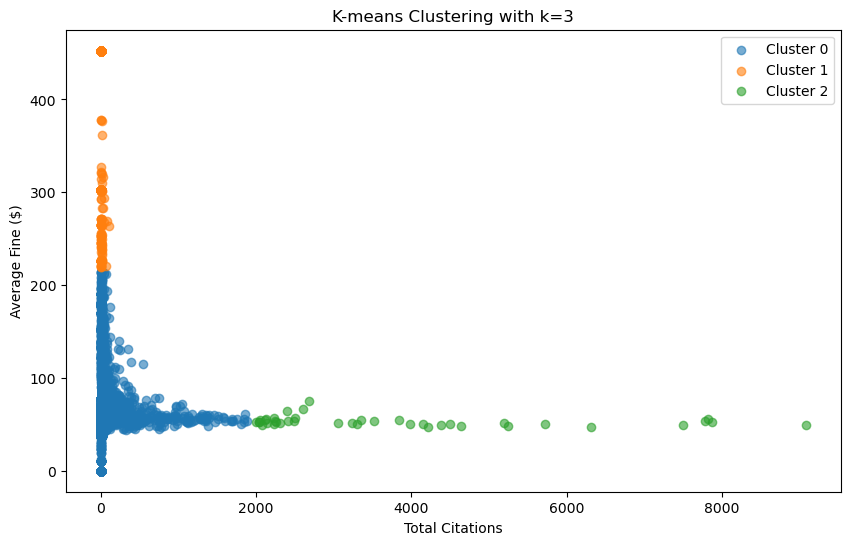

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

street_volumes = citations.groupby('location').agg({
    'citation_id': 'count',
    'vio_fine': 'mean'
})
street_volumes.columns = ['total_cites', 'avg_fine']
street_volumes = street_volumes.reset_index()

# Baseline clustering
X = street_volumes[['total_cites', 'avg_fine']]

Ks = range(2, 10)
sil_scores = []

for k in Ks:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42))
    ])
    labels = pipe.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

print(pd.DataFrame({"k": range(2,10), 'silhouette_score': sil_scores}).set_index('k'))

best_k = Ks[sil_scores.index(max(sil_scores))]
print(f"\nBest k based on silhouette: {best_k}")


final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=best_k, random_state=42))
])

street_volumes['cluster'] = final_pipe.fit_predict(X)

plt.figure(figsize=(10, 6))
for cluster in street_volumes['cluster'].unique():
    subset = street_volumes[street_volumes['cluster'] == cluster]
    plt.scatter(subset['total_cites'], subset['avg_fine'], label=f'Cluster {cluster}', alpha=0.6)

plt.xlabel('Total Citations')
plt.ylabel('Average Fine ($)')
plt.title(f'K-means Clustering with k={best_k}')
plt.legend()
plt.show()


Using San Diego’s 2024 parking citation data aggregated by street location, the K-means clustering with k = 3 separates enforcement patterns primarily by citation volume and violation severity, but the fact that the data naturally splits into three clusters rather than a clean two-tier structure suggests that even the baseline enforcement landscape is not well-organized around a simple distinction between routine and serious violations. One cluster isolates low-volume, high-fine locations tied to more serious offenses such as disabled parking and restricted curb violations, while the other two clusters both represent low-fine, routine citations that differ only by how heavily those routine violations are concentrated on certain streets. 

In [25]:
# Engineer additional features for clustering

# Day of week distribution
citations['date_issue'] = pd.to_datetime(citations['date_issue'])
citations['day_of_week'] = citations['date_issue'].dt.day_name()
dow_dist = citations.groupby(['location','day_of_week']).size().unstack(fill_value=0)
dow_dist.columns = [f'dow_{c}' for c in dow_dist.columns]

# Season distribution
def season(month):
    if month in [3,4,5]: return 'spring'
    if month in [6,7,8]: return 'summer'
    if month in [9,10,11]: return 'fall'
    return 'winter'

citations['season'] = citations['date_issue'].dt.month.apply(season)

season_dist = citations.groupby(['location','season']).size().unstack(fill_value=0)
season_dist.columns = [f'season_{c}' for c in season_dist.columns]

# Violation type distribution
vtype_dist = citations.pivot_table(
    index='location', 
    columns='vio_desc',
    values='citation_id',
    aggfunc='count',
    fill_value=0
).add_prefix("vtype_")

street_features = (
    street_volumes
    .merge(dow_dist, on='location', how='left')
    .merge(season_dist, on='location', how='left')
    .merge(vtype_dist, on='location', how='left')
    .fillna(0)
)

We added new features including day of week patterns, seasonal patterns, and violation type counts by street to move beyond a basic description of enforcement based only on size. The baseline feature set, which used only total citations and average fine, shows how much enforcement happens but not when it happens or what kinds of violations are most common at each location. By adding time based and violation type features, the model can capture how enforcement behaves over time and what types of violations dominate, rather than just how large the counts are. This gives a more complete picture of enforcement differences across streets.

In [26]:
# K-means clustering on engineered street features
X = street_features.drop(columns=['location'])

Ks = range(2, 10)
sil_scores = []

for k in Ks:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42))
    ])

    labels = pipe.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

print(pd.DataFrame({"k": range(2,10), 'silhouette_score': sil_scores}).set_index('k'))

best_k = Ks[sil_scores.index(max(sil_scores))]
print(f"\nBest k based on silhouette: {best_k}")

final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=best_k, random_state=42))
])

street_features['cluster'] = final_pipe.fit_predict(X)

   silhouette_score
k                  
2          0.981345
3          0.943783
4          0.937250
5          0.920650
6          0.920491
7          0.869563
8          0.857066
9          0.858431

Best k based on silhouette: 2


With the engineered features, the silhouette analysis clearly favors k = 2, meaning the data naturally separates into two strong groups, while the baseline model favored k = 3 mainly because of differences in citation volume. With the richer features, the data divides into one large group of typical streets with routine, low severity enforcement over time, and one small group of extreme outlier streets with very high citation activity and unusual violation patterns. This result is better than the baseline k = 3 because it shows that the main structure of the data is two groups, typical versus extreme, rather than being split into multiple routine subgroups based only on size. The engineered model therefore gives a clearer and more meaningful interpretation because it is based on when enforcement happens and what types of violations occur, not just raw counts.

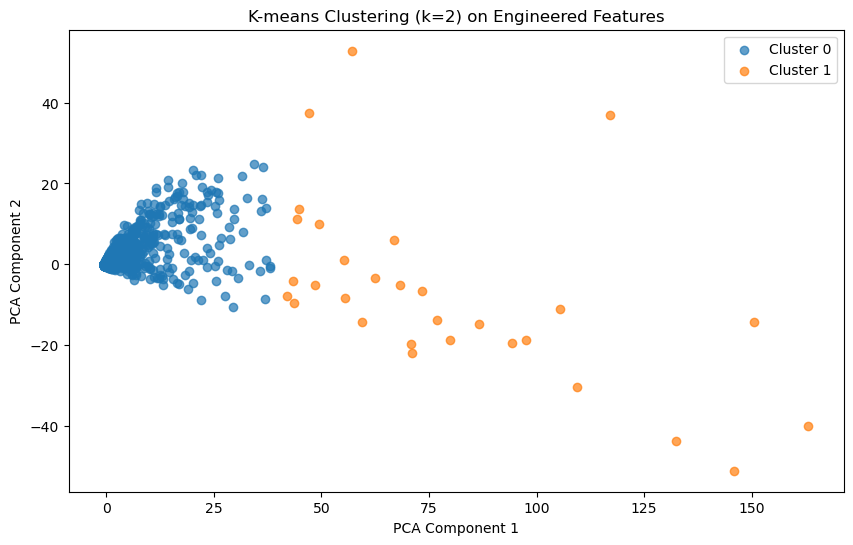

In [27]:
from sklearn.decomposition import PCA

# PCA for visualization
pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

X_pca = pca.fit_transform(X)
street_features['pca1'] = X_pca[:, 0]
street_features['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))

for cluster in sorted(street_features['cluster'].unique()):
    subset = street_features[street_features['cluster'] == cluster]
    plt.scatter(subset['pca1'], subset['pca2'], label=f'Cluster {cluster}', alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-means Clustering (k={best_k}) on Engineered Features")
plt.legend()
plt.show()


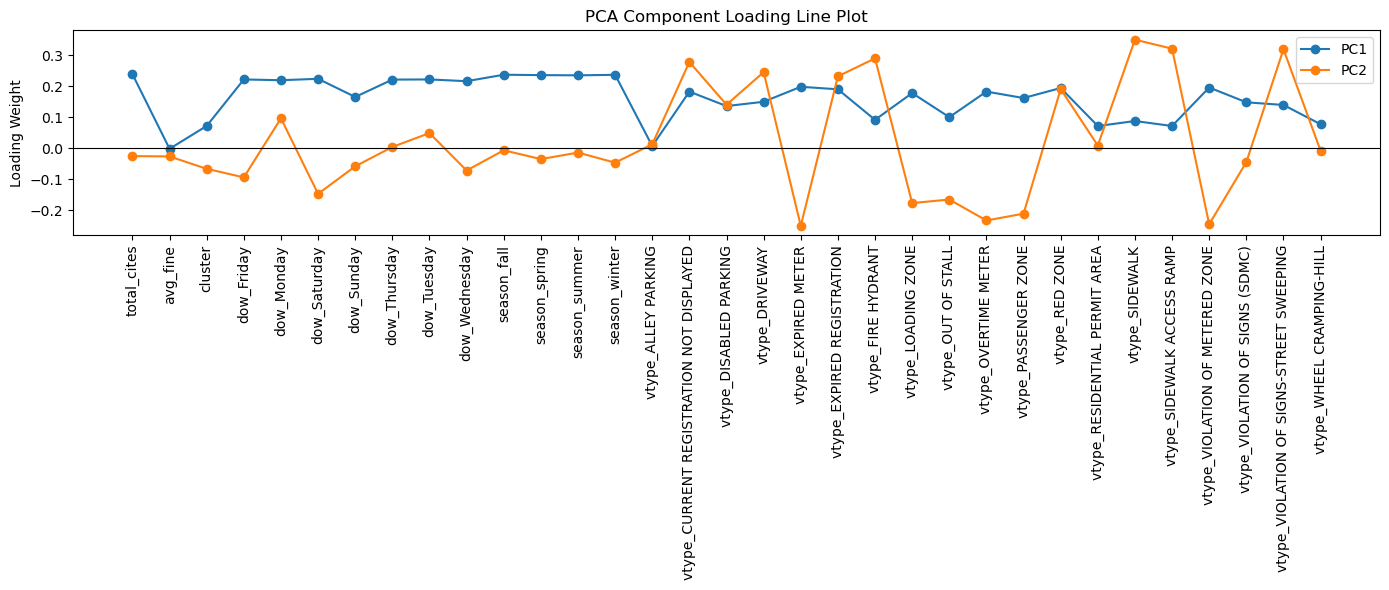

In [28]:
# PCA component loadings line plot
comp = pca.named_steps['pca']
loadings = pd.DataFrame(
    comp.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(comp.n_components_)]
)

plt.figure(figsize=(14,6))

for pc in loadings.index:
    plt.plot(loadings.columns, loadings.loc[pc], marker='o', label=pc)

plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Loading Weight")
plt.title("PCA Component Loading Line Plot")
plt.legend()
plt.tight_layout()
plt.show()


The first principal component (PC1) is driven primarily by how frequently citations occur overall, loading heavily on total citation counts as well as broad time-based patterns such as day of the week and seasonality, along with several high-frequency routine violations like metered parking, passenger loading zones, and street sweeping. This means PC1 essentially measures overall enforcement intensity. Streets with high PC1 scores are cited often across many days and seasons, while streets with low PC1 scores see relatively little enforcement activity. In contrast, the second principal component (PC2) is shaped not by how many citations occur, but by which types of violations dominate at a location, with strong positive and negative contributions from specific categories such as expired registration, fire hydrant blocking, red zone violations, sidewalk access ramp violations, and overtime meter violations. PC2 therefore captures differences in violation mix rather than volume. When K-means clustering with k = 2 is applied in this PCA space, the separation is driven almost entirely by PC1, producing one large group of typical, lower-activity streets and a much smaller group of extreme high-activity outlier streets, while PC2 explains how the types of violations differ within those groups rather than determining the split itself.

## Analysis 2 - Statistical Inference Tests

Now that we have identified clusters of streets based on citation volume and average fine amounts, we need to validate whether these clusters exhibit **statistically significant differences** in their violation patterns and fine structures. 

We will conduct three key statistical tests to address our research question:

1. **Chi-Square Test of Independence**: Tests whether violation type distribution is independent of cluster membership (i.e., do different clusters have different violation profiles?)
2. **ANOVA (Analysis of Variance)**: Tests whether mean fine amounts differ significantly across clusters

These tests will provide statistical evidence to support or refute our hypothesis that high-volume streets have significantly different citation patterns compared to low-volume streets.

### Preparation: Merge Cluster Labels with Citation Data

Before conducting statistical tests, we need to merge our cluster assignments back into the original citations dataset. This allows us to compare violation types and fine amounts across clusters.

In [29]:
# Merge cluster assignments with the original citations data
citations_with_clusters = citations.merge(
    street_features[['location', 'cluster']], 
    on='location', 
    how='left'
)

# Display cluster distribution
print("Cluster Distribution:")
print(citations_with_clusters['cluster'].value_counts().sort_index())
print(f"\nTotal citations: {len(citations_with_clusters):,}")

# Show sample of merged data
citations_with_clusters.sample(10)

Cluster Distribution:
cluster
0.0    322035
1.0    130563
Name: count, dtype: int64

Total citations: 452,702


,citation_id,date_issue,location,sector1,vio_code,vio_desc,vio_fine,day_of_week,season,cluster
398365,61257818,2024-11-12,8th ave,CSD (I) PARKING ENF,86.0126 SDMC,EXPIRED METER,42.5,Tuesday,fall,1.0
17140,59949199,2024-01-13,columbia st,CSD (I) PARKING ENF,86.0119 SDMC,LOADING ZONE,57.5,Saturday,winter,1.0
446512,61283142,2024-12-23,island ave,CSD (G) STREET SWEEPING,86.0112(E)S DMC,VIOLATION OF SIGNS-STREET SWEEPING,52.5,Monday,winter,1.0
207245,60142292,2024-06-22,15th st,CSD (I) PARKING ENF,86.0126 SDMC,VIOLATION OF METERED ZONE,42.5,Saturday,summer,1.0
185192,61016859,2024-06-06,redding rd,CSD (I) PARKING ENF,SDMC 86.2014,RESIDENTIAL PERMIT AREA,52.5,Thursday,summer,0.0
260391,61096313,2024-08-01,g st,CSD (G) STREET SWEEPING,86.0112(E)S DMC,VIOLATION OF SIGNS-STREET SWEEPING,52.5,Thursday,summer,1.0
264290,61089355,2024-08-05,32nd st,CSD (G) STREET SWEEPING,86.0112(E)S DMC,VIOLATION OF SIGNS-STREET SWEEPING,52.5,Monday,summer,0.0
431920,61279843,2024-12-11,6th ave,CSD (I) PARKING ENF,86.0105 SDMC,PASSENGER ZONE,52.5,Wednesday,winter,1.0
369177,61222155,2024-10-21,33rd st,CSD (G) STREET SWEEPING,86.0112(E)S DMC,VIOLATION OF SIGNS-STREET SWEEPING,52.5,Monday,fall,0.0
50915,60005862,2024-02-15,mission blvd,CSD (I) PARKING ENF,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5,Thursday,winter,1.0


In [30]:
citations_with_clusters[citations_with_clusters["cluster"] == 1.0]['location'].unique()

array(['5th ave', 'mission blvd', '10th ave', 'island ave', '3rd ave',
       'j st', '13th st', '8th ave', '7th ave', 'market st', '4th ave',
       'e st', 'columbia st', '6th ave', 'girard ave', 'state st', 'g st',
       'india st', '30th st', 'k st', 'kettner bl', '15th st', 'union st',
       'garnet ave', '9th ave', 'polk ave', 'hornblend st',
       'university ave', '14th st', 'orange ave'], dtype=object)

After merging the cluster assignments back into the original citation-level dataset, we observe a clear imbalance in how citations are distributed across the two clusters. Cluster 0 accounts for 322,035 citations (about 71 percent of all tickets), while Cluster 1 accounts for 130,563 citations (about 29 percent), out of a total of 452,702 citations. This confirms that most citations in San Diego come from typical streets with routine levels of enforcement, while a much smaller group of streets generates a disproportionately large share of tickets. Examining the specific street names in Cluster 1 shows that it consists of major, high-activity corridors such as Mission Boulevard, University Avenue, Market Street, Garnet Avenue, and Island Avenue, which are located in dense commercial, downtown, or beach areas. This indicates that parking enforcement in San Diego is highly concentrated in a limited set of hotspot locations, rather than being evenly distributed across all streets, reinforcing the earlier conclusion that extreme enforcement activity is spatially concentrated rather than widespread.

### Test 1: Chi-Square Test of Independence

**Research Question**: Are violation types independent of cluster membership, or do different clusters have systematically different violation type distributions?

**Hypotheses**:
- **Null Hypothesis (H₀)**: Violation type distribution is independent of cluster membership (all clusters have the same violation profile)
- **Alternative Hypothesis (H₁)**: Violation type distribution depends on cluster membership (clusters have different violation profiles)

**Method**: We construct a contingency table showing the frequency of each violation type within each cluster, then apply the chi-square test of independence.

**Significance Level**: α = 0.05

In [31]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    citations_with_clusters['cluster'], 
    citations_with_clusters['vio_desc']
)

# Perform chi-square test
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)

print("Chi-Square Test Results:")
print(f"Chi-square statistic: {chi2_stat:,.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.2e}")
print(f"\nSignificance level: α = 0.05")

if p_value < 0.05:
    print(f"Result: REJECT the null hypothesis (p < 0.05)")
    print("Conclusion: Violation type distribution is NOT independent of cluster membership.")
    print("Different clusters have statistically significant different violation profiles.")
else:
    print(f"Result: FAIL TO REJECT the null hypothesis (p ≥ 0.05)")
    print("Conclusion: No significant evidence that violation types differ across clusters.")

Chi-Square Test Results:
Chi-square statistic: 97,679.21
Degrees of freedom: 18
P-value: 0.00e+00

Significance level: α = 0.05
Result: REJECT the null hypothesis (p < 0.05)
Conclusion: Violation type distribution is NOT independent of cluster membership.
Different clusters have statistically significant different violation profiles.


The chi-square test of independence strongly rejects the null hypothesis that violation type distribution is independent of cluster membership.This provides overwhelming statistical evidence that the two clusters have systematically different violation-type profiles, meaning the clusters are not just separated by citation volume but also by the types of violations that occur within them. In practical terms, cluster membership is meaningfully associated with the kinds of infractions being issued, confirming that the clustering captures real behavioral differences in enforcement patterns rather than random variation.

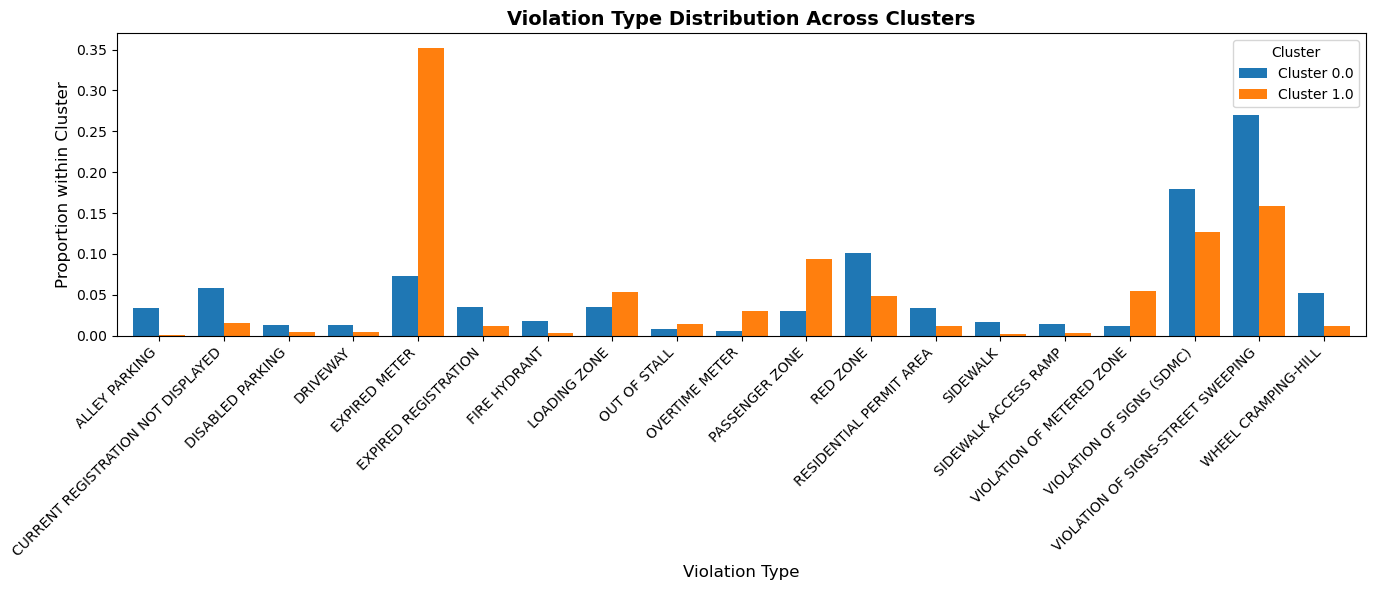

In [32]:
# Visualize the violation type proportions across clusters
proportions_by_cluster = contingency_table.div(contingency_table.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
proportions_by_cluster.T.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Violation Type', fontsize=12)
ax.set_ylabel('Proportion within Cluster', fontsize=12)
ax.set_title('Violation Type Distribution Across Clusters', fontsize=14, fontweight='bold')
ax.legend(title='Cluster', labels=[f'Cluster {i}' for i in proportions_by_cluster.index])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

The bar chart shows clear differences in violation composition between the two clusters. Cluster 1 is dominated by expired meter violations, which make up the largest share of its citations, along with noticeably higher proportions of passenger zone and metered zone violations. In contrast, Cluster 0 has a more diversified mix of routine violations, with especially large shares coming from street sweeping, violation of signs, and current registration not displayed. Serious violations such as disabled parking, sidewalk access ramp, and red zone appear at relatively low proportions in both clusters, but their relative weights still differ. Overall, the graph visually reinforces the chi-square result by showing that the extreme high-activity streets (Cluster 1) are driven primarily by short-term curbside turnover violations, while typical streets (Cluster 0) are characterized by broader, routine enforcement across many categories.

### Test 2: ANOVA - Comparing Mean Fine Amounts Across Clusters

**Research Question**: Do the clusters differ significantly in their average fine amounts?

**Hypotheses**:
- **Null Hypothesis (H₀)**: Mean fine amounts are equal across all clusters
- **Alternative Hypothesis (H₁)**: At least one cluster has a significantly different mean fine amount

**Method**: One-way ANOVA to compare mean fine amounts across the clusters identified by K-means.

**Significance Level**: α = 0.05

In [33]:
from scipy.stats import f_oneway

# Prepare fine amounts
cluster_fines = {}
print("Debugging cluster data:")

for cluster in sorted(citations_with_clusters['cluster'].unique()):
    cluster_data = citations_with_clusters[citations_with_clusters['cluster'] == cluster]
    
    # Check for missing or invalid data
    fine_values = cluster_data['vio_fine'].dropna()  # Remove NaN values
    fine_values = fine_values[np.isfinite(fine_values)]  # Remove infinite values
    fine_values = fine_values[fine_values > 0]  # Remove zero or negative fines
    
    cluster_fines[cluster] = fine_values.values
    
    print(f"Cluster {cluster}:")
    print(f"  - Total citations: {len(cluster_data):,}")
    print(f"  - Valid fine values: {len(fine_values):,}")
    print(f"  - NaN values removed: {cluster_data['vio_fine'].isna().sum()}")
    print(f"  - Infinite values removed: {(~np.isfinite(cluster_data['vio_fine'])).sum()}")
    print(f"  - Mean: ${fine_values.mean():.2f}, Std: ${fine_values.std():.2f}")
    print()

# Check if any cluster has no valid data
valid_clusters = {k: v for k, v in cluster_fines.items() if len(v) > 0}

if len(valid_clusters) < 2:
    print("ERROR: Need at least 2 clusters with valid data for statistical tests!")
    anova_p_value = np.nan
    f_stat = np.nan
else:
    print("\n" + "="*50)
    # Perform one-way ANOVA
    f_stat, anova_p_value = f_oneway(*valid_clusters.values())

print("One-Way ANOVA Results (Fine Amounts):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p_value:.6f}")
print(f"\nSignificance level: α = 0.05")

if anova_p_value < 0.05:
    print(f"Result: REJECT the null hypothesis (p < 0.05)")
    print("Conclusion: Mean fine amounts differ significantly across clusters.")
else:
    print(f"Result: FAIL TO REJECT the null hypothesis (p ≥ 0.05)")
    print("Conclusion: No significant evidence that mean fine amounts differ across clusters.")

Debugging cluster data:
Cluster 0.0:
  - Total citations: 322,035
  - Valid fine values: 320,977
  - NaN values removed: 0
  - Infinite values removed: 0
  - Mean: $62.17, Std: $49.77

Cluster 1.0:
  - Total citations: 130,563
  - Valid fine values: 130,300
  - NaN values removed: 0
  - Infinite values removed: 0
  - Mean: $52.31, Std: $30.08

Cluster nan:
  - Total citations: 0
  - Valid fine values: 0
  - NaN values removed: 0
  - Infinite values removed: 0
  - Mean: $nan, Std: $nan


One-Way ANOVA Results (Fine Amounts):
F-statistic: 4462.1293
P-value: 0.000000

Significance level: α = 0.05
Result: REJECT the null hypothesis (p < 0.05)
Conclusion: Mean fine amounts differ significantly across clusters.


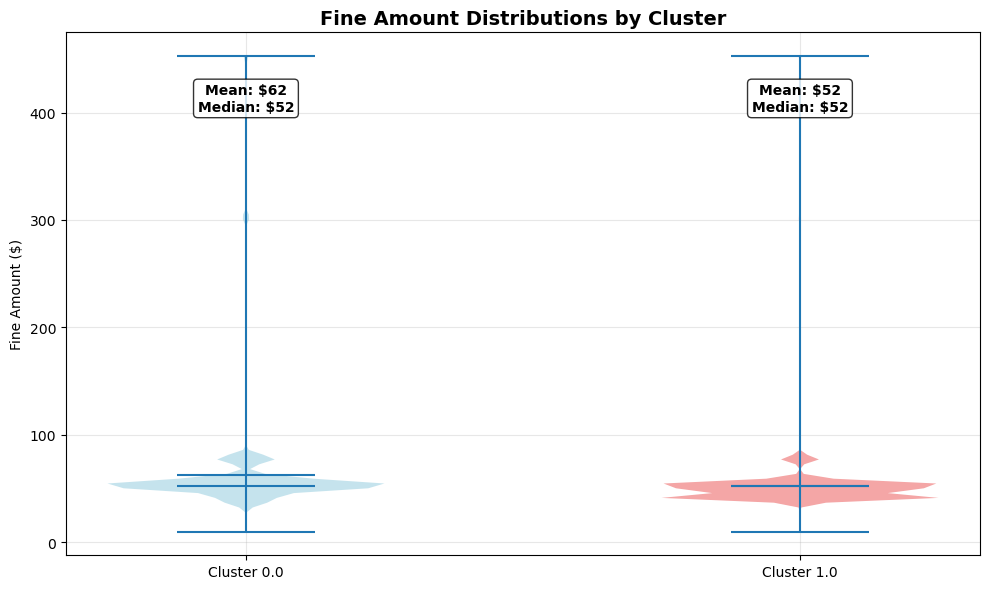


Effect Size Analysis:
Cohen's d: 0.219
Effect size interpretation: Medium effect
Difference in means: $9.87
Cluster 0.0 mean: $62.17 (±$49.77)
Cluster 1.0 mean: $52.31 (±$30.08)


In [34]:
# Visualize fine amount distributions across clusters
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Violin plot for distribution shapes
fine_data_by_cluster = [valid_clusters[cluster] for cluster in sorted(valid_clusters.keys())]
cluster_labels = [f'Cluster {cluster}' for cluster in sorted(valid_clusters.keys())]

violin_parts = ax.violinplot(fine_data_by_cluster, positions=range(1, len(valid_clusters) + 1), 
                             showmeans=True, showmedians=True)

ax.set_xticks(range(1, len(valid_clusters) + 1))
ax.set_xticklabels(cluster_labels)
ax.set_ylabel('Fine Amount ($)')
ax.set_title('Fine Amount Distributions by Cluster', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Color the violins
colors = ['lightblue', 'lightcoral', 'lightgreen'][:len(valid_clusters)]
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

# Add mean values as text
for i, data in enumerate(fine_data_by_cluster, 1):
    mean_val = np.mean(data)
    median_val = np.median(data)
    ax.text(i, ax.get_ylim()[1] * 0.9, f'Mean: ${mean_val:.0f}\nMedian: ${median_val:.0f}', 
            ha='center', va='top', fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Calculate effect size (Cohen's d) for interpretation
if len(valid_clusters) == 2:
    cluster_ids = list(valid_clusters.keys())
    data1, data2 = valid_clusters[cluster_ids[0]], valid_clusters[cluster_ids[1]]
    
    mean1, mean2 = np.mean(data1), np.mean(data2)
    std1, std2 = np.std(data1), np.std(data2)
    n1, n2 = len(data1), len(data2)
    
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    cohens_d = abs(mean1 - mean2) / pooled_std
    
    print(f"\nEffect Size Analysis:")
    print(f"Cohen's d: {cohens_d:.3f}")
    
    if cohens_d < 0.2:
        effect_interpretation = "Small effect"
    elif cohens_d < 0.5:
        effect_interpretation = "Medium effect"
    elif cohens_d < 0.8:
        effect_interpretation = "Large effect"
    else:
        effect_interpretation = "Very large effect"
    
    print(f"Effect size interpretation: {effect_interpretation}")
    print(f"Difference in means: ${abs(mean1 - mean2):.2f}")
    print(f"Cluster {cluster_ids[0]} mean: ${mean1:.2f} (±${std1:.2f})")
    print(f"Cluster {cluster_ids[1]} mean: ${mean2:.2f} (±${std2:.2f})")

The fine amount distributions show that Cluster 0 has a higher average fine ($62.17) than Cluster 1 ($52.31), while both clusters share the same median fine of $52, indicating that the difference in means is driven largely by the upper tail of higher fines in Cluster 0 rather than by typical citations. Visually, Cluster 0 also exhibits a wider spread of fine amounts, with more extreme high-fine outliers, whereas Cluster 1 is more tightly concentrated around lower fines. The effect size analysis reinforces this difference: Cohen’s d = 0.219 indicates a medium practical effect, meaning that although the $9.87 difference in average fines is statistically significant, it represents a moderate real-world shift rather than a dramatic one. Substantively, this suggests that typical streets (Cluster 0) tend to include a broader mix of fine severities, while extreme high-activity streets (Cluster 1) issue more consistently low-cost citations, likely reflecting dominance of routine curbside and meter-related violations.

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Our project uses parking citation data that does not identify individual people or vehicles. The data represents overall  patterns and trends in citations rather than tracking specific individuals, so informed consent is not applicable to our analysis.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Potential biases include possible overrepresentation of certain vehicle types and areas, due to differences in officer procedures, as well as temporary factors like construction and special event parking. Data will be aggregated over the full year to smooth and average fluctuations.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> Our data consists of citation numbers and details, and does not identify any vehicles or persons. Thus, structures to minimize personally identifiable information (PII) are not relevant to this project.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> While our parking citation dataset does not include individual-level demographic information, we will consider potential inequitable impacts of our findings. We will flag clusters that are associated with higher average fines or a higher proportion of certain violation types and examine whether these clusters disproportionately occur in neighborhoods with specific income levels, racial/ethnic compositions, or other socioeconomic characteristics.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 > Data will be stored on UCSD servers, which is encrypted by Duo.
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
 > Data will be slated for deletion if not used for more than 2 years.

### C. Analysis
 - [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> Due to differences in socioeconomic conditions, parking density, and enforcement practices, certain neighborhoods may receive disproportionately more citations than others. To mitigate this, we will use robust standard errors to reduce the influence of localized enforcement intensity.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We will clearly indicate confidence intervals, sample sizes, and limitations in our visualizations. We'll avoid cherry-picking favorable results and will present both significant and non-significant findings, along with their practical and statistical significance.

 - [ ] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> All the code used for analyses will be publically available with clear step-by-step explainations. We will make use of file versioning to revert to stable versions, should issues with developing version arise.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 > In the process of our analysis, if we were to find features that could serve as proxies for socioeconomic status or enforcement bias, we would analyse their impact further and decide whether they should be excluded from our study.

 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> The clustering analysis should be represented as a descriptive and exploratory study, not as a guide for enforcement or policy action. The identified street clusters represent statistical groupings based on citation patterns, specifically, weekly citation volume, violation-type proportions, and average fine amounts. They do not establish any relationships nor indicate intent for enforcement agencies. 

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

 > We will preserve old cluster models and datasets and ensure reproducability in our code to allow for a rollback to earlier analyses for comparison.

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
 > This analysis is conducted exclusively for research purposes and is not designed for, nor should it be applied to, targeted enforcement or punitive actions. We will make this clear in documentation accompanying our project.

## Discusison and Conclusion

In order to determine if streets in San Diego naturally divided into distinct “types” based on their citation patterns, our project examined where these parking citations are really written. After the 2024 citation data was cleaned and standardized, we discovered that while a tiny number of streets received thousands of fines, the majority of streets received a lot less. According to the revenue numbers, a few streets, such as 4th Ave., Mission Blvd., and Island Ave. generate a significant portion of the city's $26.8 million in parking fees. This suggests that parking enforcement is heavily concentrated in certain areas rather than spread out evenly. 

Using only the total citations and average fine, we initially performed K-means clustering, and the model proposed three categories. However, the optimal solution: two clusters, became much more apparent as we included additional specific information, such as the days of the week and seasons in which tickets were filed, as well as a breakdown of the different sorts of violations. One is a large collection of "normal" streets with a mix of infractions and modest enforcement, while the other is a smaller collection of "hotspot" streets, typically found in downtown or bustling business districts, with a high number of fines and particular patterns of infractions. This is consistent with previous studies that discovered enforcement and penalties are focused in certain areas rather than dispersed randomly.

This was supported by our inference testing. The chi-square test revealed a substantial correlation between cluster and violation categories, indicating that the two clusters varied not only in volume but also in the sorts of tickets being written. Hotspot streets are dominated by things like expired meters and passenger/loading zone violations, while more typical streets have more “violation of signs,” and registration-related tickets. The average fine amounts vary considerably between clusters, according to the ANOVA test: Cluster 0 (typical streets) has a higher mean fine than Cluster 1, mostly because it has more high-fine outliers. Since the impact size is moderate, the change is noticeable but not significant.

There are still significant restrictions. We don't know if these trends hold true over time because the data only spans a single year. Additionally, we only observe enforcement actions and not all parking infractions so the locations that police decide to monitor have a huge impact on the outcomes. Although previous research indicates that inequity is likely, we are unable to determine how fair or unjust the system is because we do not directly relate our clusters to neighborhood demographics or land use.

If we continued developing this project, the next steps for us would be to connect these street clusters to neighborhood level data like income, ethnicity, checking for possible inequalities. We would also increase our sample size by repeating the analysis across multiple years to see if streets move between clusters over time. Overall, our main takeaway from this project is that San Diego’s parking citations are not randomly spread out. A small number of streets act as hotspots for parking enforcement, while most streets see a lot less citations and low-intensity enforcement.
